In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [21]:
start ='2015-01-01'
end = '2025-12-31'
stock = 'GOOG'

data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [23]:
data.reset_index(inplace=True)

In [25]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2015-01-02,25.955561,26.275055,25.920447,26.163280,28951268
1,2015-01-05,25.414499,25.931820,25.374440,25.878901,41196796
2,2015-01-06,24.825466,25.528499,24.780462,25.470387,57998800
3,2015-01-07,24.782934,25.086798,24.711221,25.074730,41301082
4,2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641
...,...,...,...,...,...,...
2760,2025-12-23,315.457764,316.077322,310.531242,310.915980,13961400
2761,2025-12-24,315.447784,316.067343,313.099433,315.927427,6138200
2762,2025-12-26,314.738251,316.337130,313.499133,315.697597,6730900


In [27]:
moving_average_100_days=data.Close.rolling(100).mean()

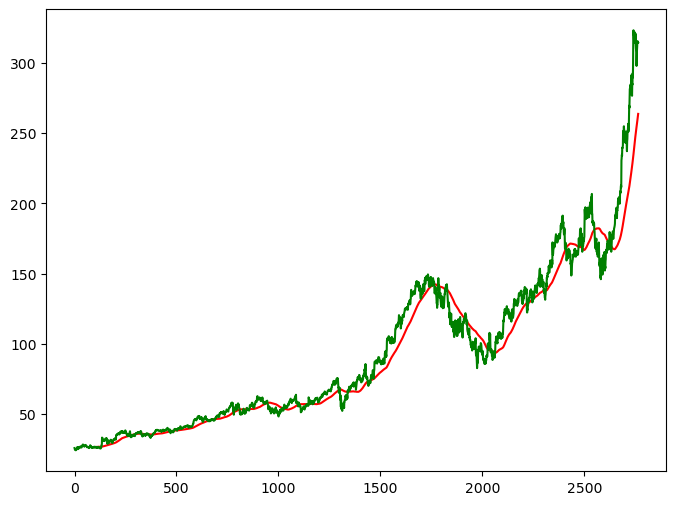

In [29]:
plt.figure(figsize=(8,6))
plt.plot(moving_average_100_days, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [48]:
moving_average_200_days=data.Close.rolling(200).mean()

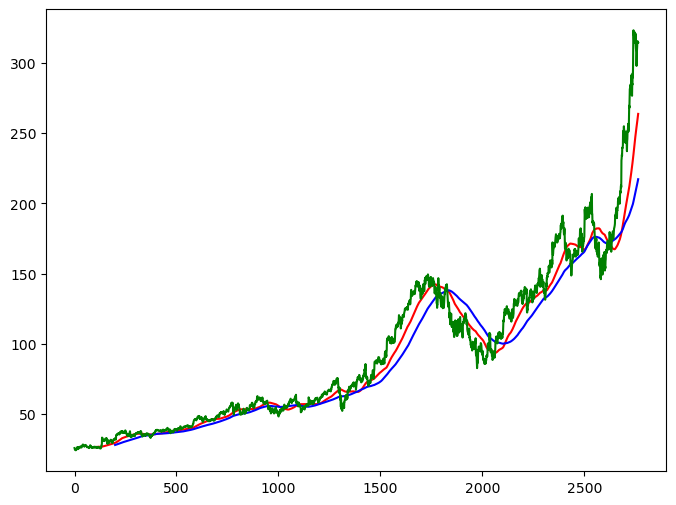

In [50]:
plt.figure(figsize=(8,6))
plt.plot(moving_average_100_days, 'r')
plt.plot(moving_average_200_days, 'b')
plt.plot(data.Close, 'g')
plt.show()

In [31]:
data.dropna(inplace=True)

In [33]:
data_train=pd.DataFrame(data.Close[0:int(len(data)*0.80)])
data_test=pd.DataFrame(data.Close[int(len(data)*0.80) : len(data)])      

In [35]:
data_train.shape[0]

2212

In [37]:
data_test.shape[0]

553

In [39]:
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler(feature_range=(0,1))

In [41]:
data_train_scale = scaler.fit_transform(data_train)

In [43]:
x=[]
y=[]
for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100 : i])
    y.append(data_train_scale[i,0])
             

In [45]:
x,y= np.array(x), np.array(y)

In [47]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [51]:
model=Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation= 'relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation= 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))
          

In [53]:
model.compile(optimizer= 'adam', loss='mean_squared_error')

In [55]:
model.fit(x,y, epochs=50, batch_size = 32, verbose=1)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - loss: 0.0376
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 0.0088
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0075
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - loss: 0.0071
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - loss: 0.0064
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - loss: 0.0064
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - loss: 0.0055
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.0062
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - loss: 0.0053
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - loss: 0.0050
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - loss: 0.0045
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - loss: 0.0047
Epoch 13/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - loss: 0.0046
Epoch 14/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0048
Epoch 15/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - 

In [57]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [59]:
past_100_days=data_train.tail(100)

In [61]:
data_test=pd.concat([past_100_days, data_test],ignore_index= True)

In [65]:
data_test_scale=scaler.fit_transform(data_test)

In [69]:
x=[]
y=[]
for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100 : i])
    y.append(data_test_scale[i,0])

x,y= np.array(x), np.array(y)

In [71]:
y_predict=model.predict(x)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


In [77]:
scale=1/scaler.scale_


In [79]:
y_predict=y_predict*scale

In [81]:
y=y*scale

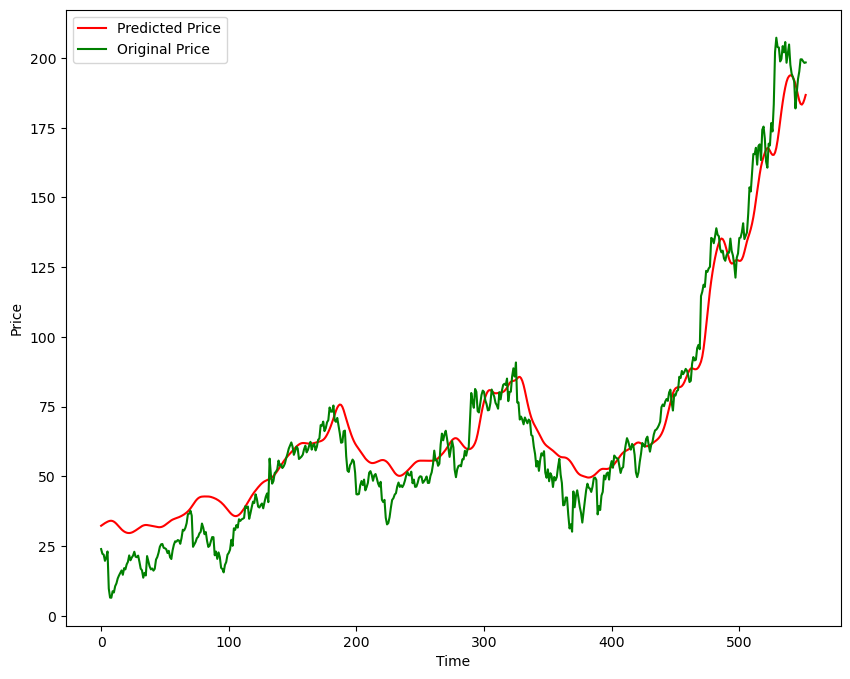

In [83]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label = 'Predicted Price')
plt.plot(y, 'g', label = 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [87]:
model.save('Stock Prediction Model.keras')